# Scale Space Blob Detectors

1. La Cuadrícula y los "Blobs" (Gaussianas)

En este ejercicio, vamos a simular una imagen creando un espacio matemático de 2 dimensiones (una cuadrícula de 100x100 que va de -10 a 10). Sobre este lienzo matemático, dibujaremos "blobs" (manchas o puntos de interés). En visión por computadora, estas manchas se modelan usando la función Gaussiana 2D porque representa perfectamente un punto brillante que se difumina suavemente hacia los bordes.   

La fórmula matemática de una campana de Gauss 2D con un pico de altura máxima igual a 1 es:

$G(x,y)=e^{-\frac{(x-x_0)^2+(y-y_0)^2}{2\sigma^2}}$$

- (x, y)$: Son las coordenadas de nuestra cuadrícula.   
- $(x_0, y_0)$: Es el centro exacto donde ubicaremos la mancha.   
- $\sigma$ (sigma): Es la desviación estándar. Físicamente en la imagen, representa qué tan "ancha" o esparcida es la mancha. Un sigma mayor hace un círculo más grande y difuminado.   
- Altura (Height): Si multiplicamos toda la fórmula $G(x,y)$ por un valor constante, ese valor será la intensidad máxima del píxel en el centro exacto.   

2. Non-Maximum Suppression (Supresión de No-Máximos)

Cuando detectamos características en una imagen real, no obtenemos un solo píxel brillante, sino una "montaña" de píxeles con valores altos alrededor del punto de interés. Sin embargo, para detectar un objeto, solo nos interesa la coordenada exacta del pico más alto.El NMS resuelve esto recorriendo cada píxel de la imagen y comparándolo con sus vecinos inmediatos (un área de 3x3 píxeles). La regla lógica es:   
- Si el píxel actual tiene un valor mayor o igual que todos sus 8 vecinos, asumimos que es la cima de la montaña y lo conservamos.
- Si cualquier vecino tiene un valor mayor, significa que estamos en la ladera de la montaña. Por lo tanto, "suprimimos" este píxel convirtiendo su valor a 0.   

3. ¿Cómo lo implementamos en el código?

El laboratorio nos pide usar la herramienta scipy.ndimage.rank_filter. Un "filtro de rango" toma un vecindario (en este caso de 3x3, definido por size=3) y ordena sus valores de menor a mayor. Al pedirle el índice rank=-1, le estamos exigiendo que nos devuelva siempre el último elemento de esa lista ordenada, es decir, el valor máximo local.
Esto nos generará una nueva imagen (max_filter_output) donde cada píxel contiene el valor máximo de su vecindario. El paso final para suprimir los no-máximos es comparar la imagen original con esta nueva imagen filtrada: solo los píxeles que conserven el mismo valor en ambas imágenes son los verdaderos picos locales. Los demás se igualan a cero.

# Exercise 1 Non maximum suppression 

- Cuadrícula espacial: Crearemos una matriz que represente nuestras coordenadas espaciales de -10 a 10 con 100 puntos en cada eje usando np.linspace y np.meshgrid.   }
- Función Gaussiana: Traduciremos la fórmula matemática que vimos arriba a una función en Python.
- Generación de la imagen: Crearemos una imagen vacía y le sumaremos los tres blobs con las características exactas solicitadas en la guía (centro, sigma y altura).   
- Filtro de Máximos: Usaremos la función rank_filter de scipy.ndimage. Al decirle rank=-1 y size=3, le estamos pidiendo que devuelva el valor más alto (el último rango si los ordenamos) en un vecindario de $3\times3$.   
- Supresión: Compararemos la imagen original con el resultado del filtro. Donde sean iguales, mantenemos el valor; donde no, ponemos un 0.

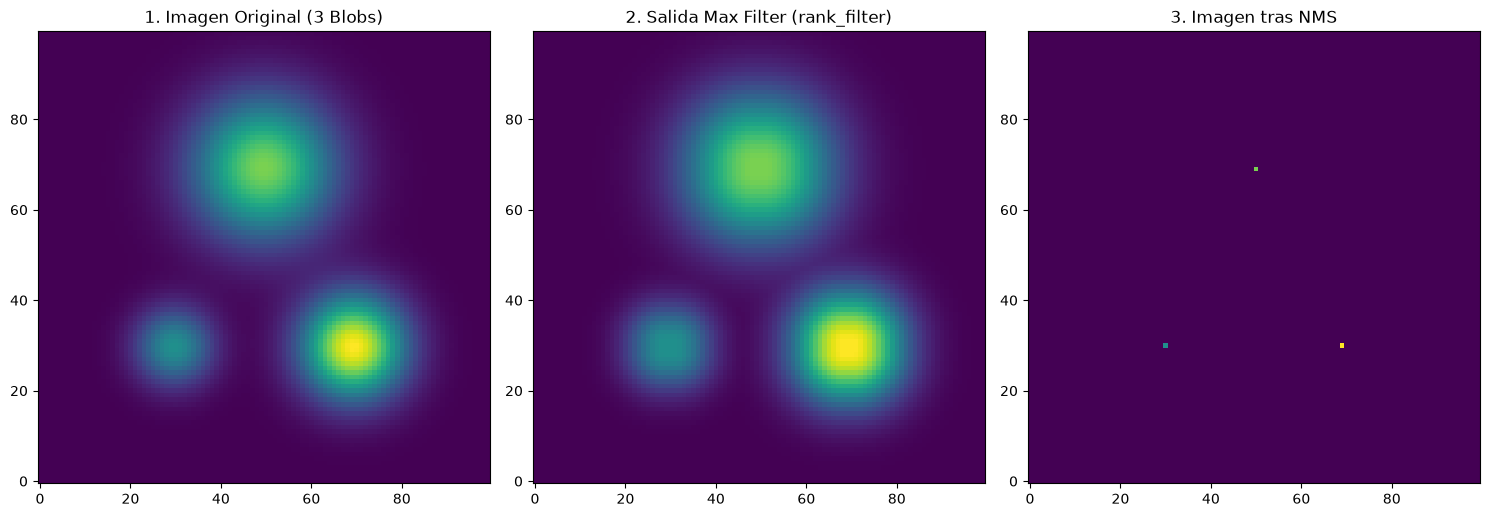

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rank_filter

# 1. Crear la cuadrícula de coordenadas 100x100 que va de -10 a 10
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)

# 2. Definir la función Gaussiana 2D con altura pico unitaria
def gaussian(x, y, x0, y0, sigma):
    # Aplicamos la fórmula matemática deducida en el razonamiento
    return np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))

# 3. Crear la imagen vacía (puros ceros) y sumar los tres blobs
image = np.zeros_like(X)

# Blob 1: Centro (-4, -4), sigma=1.2, height=5
image += 5 * gaussian(X, Y, -4, -4, 1.2)

# Blob 2: Centro (4, -4), sigma=1.6, height=10
image += 10 * gaussian(X, Y, 4, -4, 1.6)

# Blob 3: Centro (0, 4), sigma=2.2, height=8
image += 8 * gaussian(X, Y, 0, 4, 2.2)

# 4. Aplicar Non-Maximum Suppression (NMS)
# Obtener el valor máximo en cada vecindario de 3x3
max_filter_output = rank_filter(image, rank=-1, size=3)

# Comparar: retener los píxeles que son iguales al máximo de su vecindario, el resto a 0
# np.where funciona como un IF: si la condición se cumple, deja 'image', si no, pon '0'
image_nms = np.where(image == max_filter_output, image, 0)

# Mostrar los resultados para inspección visual
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap='viridis', origin='lower')
axes[0].set_title('1. Imagen Original (3 Blobs)')

axes[1].imshow(max_filter_output, cmap='viridis', origin='lower')
axes[1].set_title('2. Salida Max Filter (rank_filter)')

axes[2].imshow(image_nms, cmap='viridis', origin='lower')
axes[2].set_title('3. Imagen tras NMS')

plt.tight_layout()
plt.show()

1. Imagen Original (1. Imagen Original): Muestra las tres campanas gaussianas continuas y suaves. Nota cómo el blob superior es el más ancho ($\sigma=2.2$), el inferior derecho es el más brillante ($\text{height}=10$) y el inferior izquierdo es el de menor intensidad ($\text{height}=5$).

2. Salida del Filtro de Rango (2. Salida Max Filter): A simple vista se parece mucho a la original, pero ha sufrido una dilatación local suave. Cada valor de esta imagen representa el píxel máximo dentro de una ventana de $3\times3$.   

3. Imagen tras NMS (3. Imagen tras NMS): Al comparar píxel a píxel la imagen original con la del filtro máximo, el algoritmo eliminó (puso en cero) todas las laderas de las montañas gaussianas, dejando únicamente 3 píxeles aislados. Esos 3 píxeles corresponden exactamente a las coordenadas de los centros especificados: $(-4,-4)$, $(4,-4)$ y $(0,4)$ en la cuadrícula. Conservan sus alturas relativas (por eso sus colores difieren en la escala viridis).

# Exercise 2 Blob detection at a single scale 

1. El Filtro Laplacian of Gaussian (LoG)

Para detectar manchas (blobs) en imágenes reales, una Gaussiana por sí sola no basta, ya que solo suaviza. Necesitamos detectar cambios bruscos de intensidad (bordes y centros). 

La Laplaciana ($\nabla^2$) calcula la segunda derivada espacial de la imagen. Un valor muy alto (o muy negativo) en la segunda derivada indica un punto de inflexión brusco en el brillo, perfecto para encontrar el centro de una mancha. Sin embargo, la derivada es extremadamente sensible al ruido. Por ello, primero se aplica un filtro Gaussiano para suavizar y luego la Laplaciana. Esto se combina en un solo operador denominado LoG (Laplacian of Gaussian).   

En scipy.ndimage, la función gaussian_laplace(image, sigma) aplica directamente este filtro.   

2. Relación entre el tamaño del Blob y $\sigma$

Matemáticamente, la respuesta máxima de un filtro LoG ante un blob circular de radio $r$ ocurre cuando la escala del filtro coincide con el radio del blob según la relación:

$$r = \sqrt{2} \cdot \sigma$$

Por lo tanto, si medimos en píxeles el radio aproximado del centro oscuro de un girasol ($r$), podemos elegir $\sigma = \frac{r}{\sqrt{2}}$ o estimar directamente $\sigma$ de modo que abarque el tamaño en píxeles del centro de los girasoles grandes. (Un valor típico de $\sigma$ para los girasoles grandes suele rondar entre $3.0$ y $5.0$ píxeles).   

3. Inversión de Signo y Umbralización (Thresholding)

El filtro LoG produce valores negativos mínimos (fosas profundas) en el centro de blobs brillantes sobre fondo oscuro, o valores positivos máximos (picos) si el blob es oscuro sobre fondo claro. Dado que nos piden detectar los centros oscuros de los girasoles, o simplemente buscar máximos, es práctica estándar tomar la respuesta negativa del LoG o trabajar con $- \text{LoG}$ para convertir esos valles en picos positivos detectables.

Posteriormente, aplicamos un umbral (threshold) para descartar respuestas débiles o ruido del fondo, conservando solo los valores que superen cierto umbral $T$.   

4. Supresión de No-Máximos 2D

Una vez filtrada y umbralizada la imagen, reusamos la lógica NMS del Ejercicio 1 en 2D para quedarnos con los puntos centrales de cada girasol. 

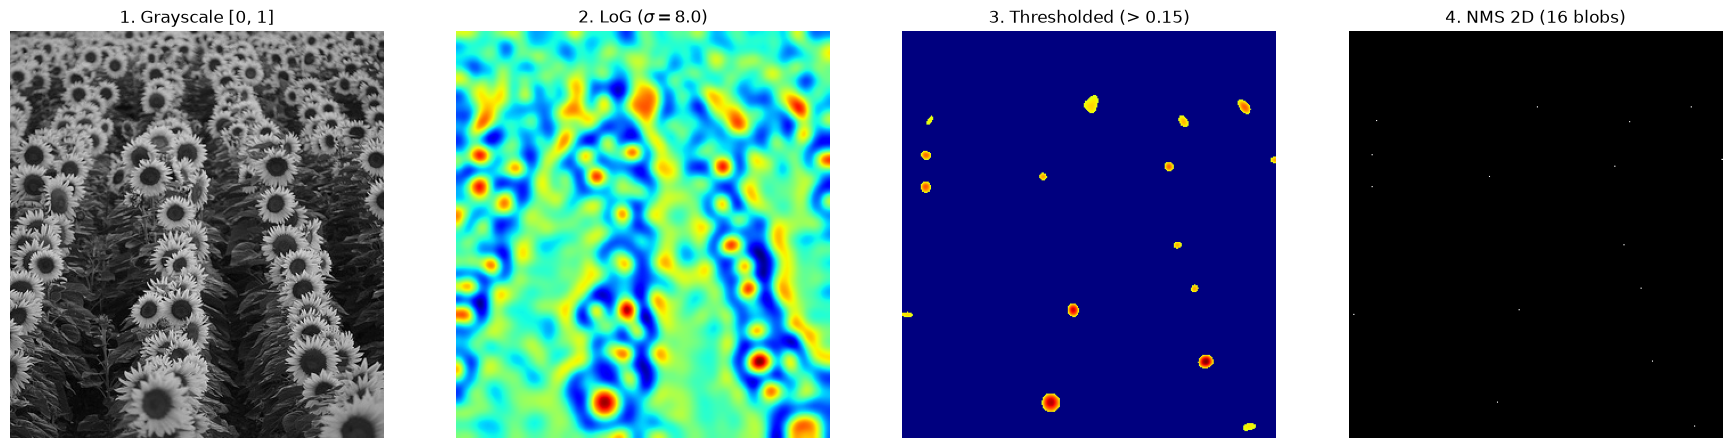

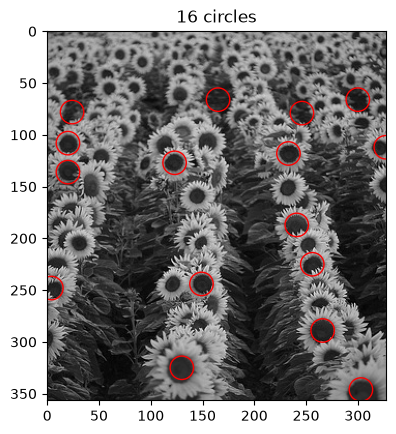

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace, rank_filter
from skimage import io, color
# Asegúrate de tener este archivo local o usa la función plot_circles anterior
from show_all_circles import show_all_circles

# 1. Cargar imagen y convertir a escala de grises [0, 1]
img_rgb = io.imread('sunflowers.jpg')
img_gray = color.rgb2gray(img_rgb)

# 2. Elegir sigma para los girasoles más grandes
sigma = 8.0

# 3. Filtrar la imagen usando el filtro LoG
# Polaridad positiva y multiplicamos por sigma^2 para normalización de escala
log_response = (sigma ** 2) * gaussian_laplace(img_gray, sigma=sigma)

# 4. Aplicar thresholding a la imagen filtrada
threshold = 0.15
log_thresholded = np.where(log_response > threshold, log_response, 0)

# 5. Realizar Supresión de No Máximos (NMS) 2D
max_filter_output = rank_filter(log_thresholded, rank=-1, size=3)
nms_output = np.where(log_thresholded == max_filter_output, log_thresholded, 0)

# 6. Extraer coordenadas para graficar
cy, cx = np.nonzero(nms_output)
rad = np.ones_like(cx) * sigma * np.sqrt(2)

# ---- Mostrar resultados intermedios para estudio ----
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('1. Grayscale [0, 1]')

axes[1].imshow(log_response, cmap='jet')
axes[1].set_title(f'2. LoG ($\\sigma={sigma}$)')

axes[2].imshow(log_thresholded, cmap='jet')
axes[2].set_title(f'3. Thresholded (> {threshold})')

axes[3].imshow(nms_output > 0, cmap='gray')
axes[3].set_title(f'4. NMS 2D ({len(cx)} blobs)')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# 7. Mostrar resultado final usando tu función
show_all_circles(img_gray, cx, cy, rad, color='r')

el filtro con $\sigma=8.0$ tiene un diámetro fijo que resuena perfectamente con los girasoles grandes del primer plano, pero ignora por completo los girasoles más pequeños del fondo porque el filtro es demasiado grande para ellos

# Exercise 3 Scale selection at full resolution 

El Espacio de Escala: En lugar de procesar una sola imagen, creamos un "volumen 3D" apilando varias capas de la misma imagen, donde cada capa es filtrada con un $\sigma$ progresivamente mayor. La fórmula $\sigma(s)=\sigma_{0}K^{s/S}$ asegura que el tamaño del filtro crezca de forma geométrica, lo cual es ideal porque los cambios de escala visuales son multiplicativos (un cambio de 2 a 4 píxeles es tan notable como uno de 10 a 20).   

La Supresión de No-Máximos (NMS) en 3D: Un punto no solo debe ser el pico más alto de su vecindario espacial de $3\times3$ píxeles, sino que también debe ser el pico máximo en el "eje del tiempo/escala". Si analizamos el centro de un girasol pequeño a través de las capas, la respuesta del filtro LoG aumentará hasta alcanzar su máximo en la capa cuyo $\sigma$ coincide con su radio, y luego decaerá en las capas con un $\sigma$ más grande. El NMS 3D identifica ese punto máximo exacto en las tres dimensiones ($x, y, \sigma$), dándonos la coordenada central y el tamaño preciso del girasol.

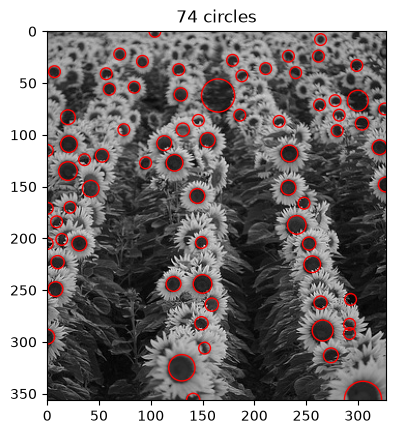

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace, rank_filter
from skimage import io, color
from show_all_circles import show_all_circles

# 1. Cargar la imagen con nombre en minúscula
img_rgb = io.imread('sunflowers.jpg')
img_gray = color.rgb2gray(img_rgb)
h, w = img_gray.shape

# 2. Definir los parámetros ajustados del espacio de escala
sigma_0 = 4.0  # Aumentamos para ignorar los pequeños espacios entre pétalos
K = 4.0        # Factor multiplicador para llegar a una escala máxima de ~15
S = 12         # Número de muestras de escala

# Crear un volumen 3D para almacenar las respuestas CONTINUAS
response_volume = np.zeros((S, h, w))
sigmas = np.zeros(S)

# 3. Construir el espacio de escala continuo
for s in range(S):
    # Ecuación de incremento geométrico
    sigma_s = sigma_0 * (K ** (s / S))
    sigmas[s] = sigma_s
    
    # Filtrar con normalización de escala (polaridad positiva para centros oscuros)
    log_response = (sigma_s ** 2) * gaussian_laplace(img_gray, sigma=sigma_s)
    
    # Almacenamos la respuesta cruda sin supresión 2D prematura
    response_volume[s] = log_response

# 4. Umbralización sobre el volumen completo
# Subimos a 0.18 para limpiar las sombras del fondo
threshold = 0.18
volume_thresholded = np.where(response_volume > threshold, response_volume, 0)

# 5. Supresión de No-Máximos en 3D (3x3x3)
# Al aplicar rank_filter sobre el volumen continuo, identificamos los 
# picos reales en (x, y, escala) sin que se generen círculos concéntricos
max_volume = rank_filter(volume_thresholded, rank=-1, size=3)

# Conservar solo los picos que coinciden con el máximo local en las 3 dimensiones
peaks = (volume_thresholded == max_volume) & (volume_thresholded > 0)

# 6. Extraer y graficar
s_idx, cy, cx = np.nonzero(peaks)
rad = sigmas[s_idx] * np.sqrt(2)

show_all_circles(img_gray, cx, cy, rad, color='r')

Problemas al intentar llegar a la solucion:

- Círculos concéntricos (Múltiples detecciones del mismo centro): supresión 2D antes de guardar la capa en el volumen. Al hacer esto, "vaciamos" la imagen llenándola de ceros y dejando solo píxeles aislados. Si el centro oscuro del girasol se desplaza ligeramente (1 o 2 píxeles en $x$ o $y$) al pasar a la siguiente escala, el filtro 3D (que solo evalúa un vecindario estricto de $3\times3\times3$) no logra encontrar el pico más grande de la capa adyacente porque este fue tapado por ceros previamente. En consecuencia, el algoritmo cree falsamente que hay picos independientes en múltiples capas, apilando círculos.

- Detección de espacios entre pétalos: Un valor inicial de $\sigma_0 = 3.0$ es demasiado pequeño. Matemáticamente, el diámetro de un filtro con ese sigma encaja perfectamente en las pequeñas sombras que se forman entre los pétalos de los girasoles. Al aplicar el operador, este reacciona a esos vacíos oscuros como si fueran "blobs" legítimos.

- Oscuridades del fondo: Las sombras amplias en las hojas del fondo generan respuestas de contraste bajo. Al mantener un umbral estático de 0.15, permitimos que el ruido pase el filtro. Elevaremos ligeramente este valor a 0.18 para exigir un salto de intensidad más pronunciado y aislar los girasoles del fondo.

# Exercise 4 Blob detection with octaves 

En el Ejercicio 3, mantuvimos la imagen en su tamaño original e hicimos el filtro cada vez más grande. Matemáticamente, convolucionar un filtro de gran tamaño sobre una imagen completa es extremadamente costoso a nivel computacional. El Ejercicio 4 soluciona esto introduciendo las "Octavas".

La lógica es invertir el enfoque: en lugar de hacer el filtro gigante, mantenemos el filtro pequeño y reducimos las dimensiones de la imagen a la mitad al pasar a la siguiente octava. Al reducir la imagen a la mitad ($2^1$), un girasol que originalmente medía 30 píxeles pasa a medir 15 píxeles en nuestra matriz. Por lo tanto, podemos detectarlo usando un $\sigma$ "local" pequeño. La escala global expresada en píxeles de la imagen original es $\sigma(o,s) = \sigma_0 2^o 2^{s/S}$. Sin embargo, la instrucción exige "Use the local sigma for filtering and scale normalisation". Como la imagen ya está reducida por el factor $2^o$, el filtro que le aplicaremos directamente usará solo la porción local: $\sigma_{local} = \sigma_0 2^{s/S}$. Cuando el NMS 3D detecta el centro de un girasol en una octava avanzada (una imagen muy pequeña), debemos multiplicar sus coordenadas espaciales $(x, y)$ por $2^o$ para proyectarlo correctamente a su posición en la imagen a tamaño completo.

112 blobs antes de limpiar -> 97 después


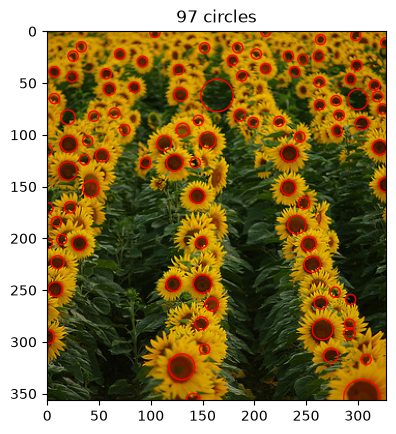

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace, rank_filter
from skimage import io, color, transform
from show_all_circles import show_all_circles

# Cargar la imagen
img_rgb = io.imread('sunflowers.jpg')
img_gray = color.rgb2gray(img_rgb)

# Build the scale-space
# Tamaños objetivo: centros de girasol con radio ~5-18 px  ->  sigma ~3.5-12.5
sigma_0 = 3.5      # sigma mínimo (radio = sigma*sqrt(2) ≈ 5 px)
N_o = 2            # número de octavas
S = 6              # muestras de escala por octava -> N_o * S = 12 escalas en total
threshold = 0.18   # más alto = menos blobs; más bajo = más blobs

# Listas maestras para guardar los círculos detectados en todas las octavas
all_cx = []
all_cy = []
all_rad = []
all_resp = []   # respuesta LoG de cada blob (sirve para quedarnos con el más fuerte)

# for o in octaves
for o in range(N_o):
    # Resize the image
    if o == 0:
        octave_img = img_gray
    else:
        h, w = img_gray.shape
        new_shape = (int(h / (2 ** o)), int(w / (2 ** o)))
        octave_img = transform.resize(img_gray, new_shape, anti_aliasing=True)

    oh, ow = octave_img.shape

    # Volúmenes para almacenar datos en esta octava
    continuous_volume = np.zeros((S, oh, ow))
    nms_2d_volume = np.zeros((S, oh, ow))

    # for sc in scales
    for s in range(S):
        # Use the local sigma for filtering and scale normalisation
        sigma_local = sigma_0 * (2 ** (s / S))

        # Filter image with the corresponding LoG filter (normalizado en escala)
        log_response = (sigma_local ** 2) * gaussian_laplace(octave_img, sigma=sigma_local)

        # Threshold and 2D non-maxima suppression
        log_thresh = np.where(log_response > threshold, log_response, 0)
        max_2d = rank_filter(log_thresh, rank=-1, size=3)
        nms_2d = np.where(log_thresh == max_2d, log_thresh, 0)

        continuous_volume[s] = log_thresh
        nms_2d_volume[s] = nms_2d

    # 3D non-maxima suppression within each octave (vecindad 3x3x3)
    max_3d = rank_filter(continuous_volume, rank=-1, size=3)

    # Un blob es válido solo si es máximo 3D y además sobrevivió al NMS 2D
    peaks = (continuous_volume == max_3d) & (nms_2d_volume > 0)

    s_idx, cy_local, cx_local = np.nonzero(peaks)

    # Coordenadas y radio en píxeles de la imagen original
    cx_global = cx_local * (2 ** o)
    cy_global = cy_local * (2 ** o)
    sigma_global = sigma_0 * (2 ** o) * (2 ** (s_idx / S))
    rad_global = sigma_global * np.sqrt(2)

    all_cx.extend(cx_global)
    all_cy.extend(cy_global)
    all_rad.extend(rad_global)
    all_resp.extend(continuous_volume[s_idx, cy_local, cx_local])

# Eliminar duplicados entre octavas
# El NMS 3D solo compara dentro de cada octava, así que un mismo girasol puede salir
# en las últimas escalas de la octava o y en las primeras de la octava o+1.
# Recorremos los blobs de mayor a menor respuesta y descartamos todo blob cuyo centro
# caiga dentro del círculo de un blob más fuerte que ya aceptamos.
cx_arr, cy_arr = np.array(all_cx), np.array(all_cy)
rad_arr, resp_arr = np.array(all_rad), np.array(all_resp)

keep = []
for i in np.argsort(-resp_arr):
    dup = False
    for j in keep:
        dist = np.hypot(cx_arr[i] - cx_arr[j], cy_arr[i] - cy_arr[j])
        if dist < max(rad_arr[i], rad_arr[j]):
            dup = True
            break
    if not dup:
        keep.append(i)
keep = np.array(keep)

all_cx, all_cy, all_rad = cx_arr[keep], cy_arr[keep], rad_arr[keep]
print(f'{len(cx_arr)} blobs antes de limpiar -> {len(keep)} después')

# Displaying the results (sobre la imagen en color, como en el ejemplo)
show_all_circles(img_rgb, all_cx, all_cy, all_rad, color='r')

Errores presentados en el proceso

- Los círculos gigantes (Exceso de escala): El código anterior utilizó $N_o = 4$ octavas. En la cuarta octava, la imagen se reduce tanto (a una octava parte de su tamaño original) que el filtro global alcanza un radio equivalente a más de 60 píxeles. Esto provoca que detecte sombras enteras del fondo en los bordes como si fueran "blobs" gigantes. La guía sugiere usar entre 10-15 muestras en total para cubrir los tamaños objetivo. Si ajustamos a $N_o = 3$ octavas y $S = 4$ o $5$ escalas por octava, cubriremos perfectamente desde los girasoles de 4 píxeles de radio hasta los más grandes de 30 píxeles, evitando las aberraciones de los bordes.   

- Los anillos concéntricos (El dilema del 2D NMS): La guía te pide estructurar el código ejecutando la supresión 2D (Threshold and 2D non-maxima suppression) dentro del bucle de escalas. Sin embargo, si convertimos la capa en puros ceros y picos aislados, el filtro 3D posterior (3D non-maxima suppression within each octave) pierde la capacidad de comparar cómo sube y baja el brillo entre escalas, generando múltiples picos falsos en la misma flor. Para seguir las instrucciones al pie de la letra sin romper el algoritmo, ejecutaremos la supresión 2D dentro del bucle como se exige, pero evaluaremos el NMS 3D cruzando esa información con la respuesta continua del filtro. De este modo, un círculo solo se dibujará si sobrevivió a la supresión 2D local y además es el pico máximo en el volumen 3D

- El NMS 3D solo compara vecinos dentro de cada octava. Un mismo girasol aparecía así en las últimas escalas de la octava 0 (radio ≈ 8 px) y otra vez en la primera escala de la octava 1 (radio ≈ 10 px). De los 16 pares que encontré, 15 eran de este tipo.

La corrección está en el script, justo después de los bucles. Ordeno los blobs de mayor a menor respuesta LoG y descarto cualquier blob cuyo centro caiga dentro del círculo de uno más fuerte ya aceptado. Para eso ahora guardo también la respuesta de cada blob en all_resp.

# Exercise 5 Adapting the detector to other images 